In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import time
import tensorflow as tf

In [9]:
def func(t):
  return np.sin(1+t*np.pi*2)/2+1

def get_regression_dataset(start=0, end=3, seed=1, samples=80):
  t = np.linspace(start, end, samples)
  oryginal = func(t)
  np.random.seed(seed)
  noisy = oryginal + np.random.normal(0, 0.2, samples)
  return t, noisy, oryginal

In [10]:
x_train, y_train, r_org = get_regression_dataset(0,5,1,200)
x_test, y_test, r_org_test = get_regression_dataset(0,5,2,200)

x_train_reshaped = x_train.reshape(-1,1)
x_test_reshaped = x_test.reshape(-1,1)

In [15]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),                                
    tf.keras.layers.Dense(128, activation='relu'),              
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

class ProgressMonitor(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 == 0:
            print(f"Epoka {epoch:>4} | Błąd treningowy: {logs['loss']:.4f} | Błąd testowy: {logs['val_loss']:.4f}")

history = model.fit(
    x_train_reshaped,
    y_train,
    epochs=1500,
    validation_data=(x_test_reshaped, y_test),
    verbose=0,
    callbacks=[ProgressMonitor()]
)

train_evaluation = model.evaluate(x_train_reshaped, y_train, verbose=0)

test_evaluation = model.evaluate(x_test_reshaped, y_test, verbose=0)

train_loss_final = train_evaluation[0] if type(train_evaluation) is list else train_evaluation
test_loss_final = test_evaluation[0] if type(test_evaluation) is list else test_evaluation

print(f"Błąd (Loss) na zbiorze treningowym: {train_loss_final:.4f}")
print(f"Błąd (Loss) na zbiorze testowym: {test_loss_final:.4f}")

Epoka    0 | Błąd treningowy: 0.7714 | Błąd testowy: 0.4000
Epoka  100 | Błąd treningowy: 0.1405 | Błąd testowy: 0.1582
Epoka  200 | Błąd treningowy: 0.1254 | Błąd testowy: 0.1435
Epoka  300 | Błąd treningowy: 0.1171 | Błąd testowy: 0.1369
Epoka  400 | Błąd treningowy: 0.1073 | Błąd testowy: 0.1219
Epoka  500 | Błąd treningowy: 0.0998 | Błąd testowy: 0.1179
Epoka  600 | Błąd treningowy: 0.0935 | Błąd testowy: 0.1093
Epoka  700 | Błąd treningowy: 0.0868 | Błąd testowy: 0.1016
Epoka  800 | Błąd treningowy: 0.0805 | Błąd testowy: 0.0961
Epoka  900 | Błąd treningowy: 0.0749 | Błąd testowy: 0.0927
Epoka 1000 | Błąd treningowy: 0.0681 | Błąd testowy: 0.0908
Epoka 1100 | Błąd treningowy: 0.0719 | Błąd testowy: 0.0991
Epoka 1200 | Błąd treningowy: 0.0703 | Błąd testowy: 0.0917
Epoka 1300 | Błąd treningowy: 0.0624 | Błąd testowy: 0.0816
Epoka 1400 | Błąd treningowy: 0.0553 | Błąd testowy: 0.0758
Błąd (Loss) na zbiorze treningowym: 0.0541
Błąd (Loss) na zbiorze testowym: 0.0784


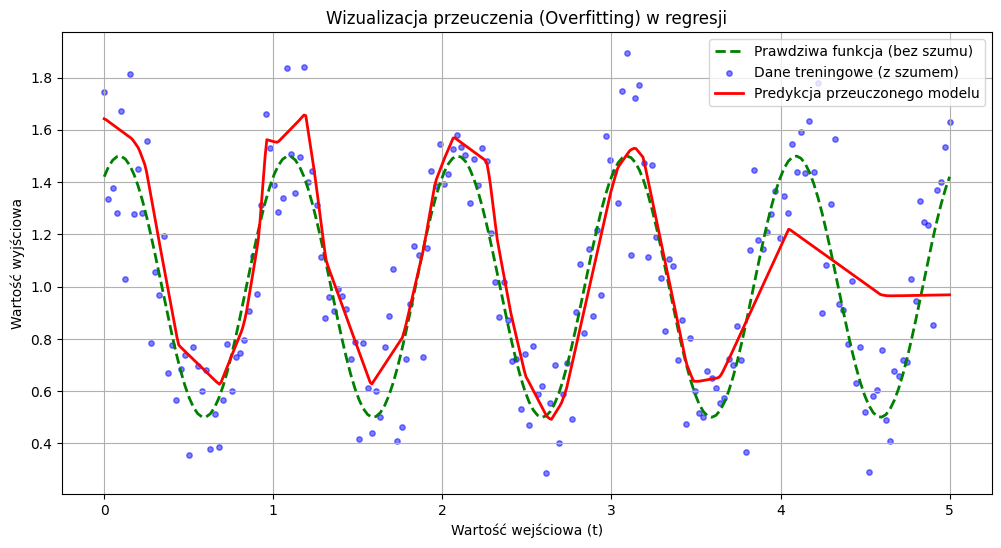

In [17]:
t_plot = np.linspace(0, 5, 500).reshape(-1, 1)

predictions = model.predict(t_plot, verbose=0)

plt.figure(figsize=(12, 6))

t_original = np.linspace(0, 5, 200)
plt.plot(t_original, r_org, color='green', label='Prawdziwa funkcja (bez szumu)', linewidth=2, linestyle='--')

plt.scatter(x_train, y_train, color='blue', s=15, alpha=0.5, label='Dane treningowe (z szumem)')

plt.plot(t_plot, predictions, color='red', label='Predykcja przeuczonego modelu', linewidth=2)

plt.title('Wizualizacja przeuczenia (Overfitting) w regresji')
plt.xlabel('Wartość wejściowa (t)')
plt.ylabel('Wartość wyjściowa')
plt.legend()
plt.grid(True)
plt.show()

2. Przeprowadź trzy eksperymenty, stosując każdą z poniższych metod regularyzacji:

    • Eksperyment 1: Użyj metody dropout.
    
    • Eksperyment 2: Użyj regularyzacji L1.
    
    • Eksperyment 3: Użyj regularyzacji L2.

Eksperyment 1: Metoda dropout

In [21]:
model_dropout = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),                                 
    
    tf.keras.layers.Dense(128, activation='relu'),              
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.05), 
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.05), 
    
    tf.keras.layers.Dense(1)
])

model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = model_dropout.fit(
    x_train_reshaped,
    y_train,
    epochs=1500,
    validation_data=(x_test_reshaped, y_test),
    verbose=0,
    callbacks=[ProgressMonitor()]
)

train_evaluation_dropout = model_dropout.evaluate(x_train_reshaped, y_train, verbose=0)
test_evaluation_dropout = model_dropout.evaluate(x_test_reshaped, y_test, verbose=0)

train_loss_final_dropout = train_evaluation_dropout[0] if type(train_evaluation_dropout) is list else train_evaluation_dropout
test_loss_final_dropout = test_evaluation_dropout[0] if type(test_evaluation_dropout) is list else test_evaluation_dropout

print(f"Błąd (Loss) na zbiorze treningowym (Dropout): {train_loss_final_dropout:.4f}")
print(f"Błąd (Loss) na zbiorze testowym (Dropout): {test_loss_final_dropout:.4f}")

Epoka    0 | Błąd treningowy: 0.7995 | Błąd testowy: 0.4168
Epoka  100 | Błąd treningowy: 0.1484 | Błąd testowy: 0.1704
Epoka  200 | Błąd treningowy: 0.1347 | Błąd testowy: 0.1555
Epoka  300 | Błąd treningowy: 0.1247 | Błąd testowy: 0.1463
Epoka  400 | Błąd treningowy: 0.1266 | Błąd testowy: 0.1350
Epoka  500 | Błąd treningowy: 0.1181 | Błąd testowy: 0.1272
Epoka  600 | Błąd treningowy: 0.1067 | Błąd testowy: 0.1189
Epoka  700 | Błąd treningowy: 0.0941 | Błąd testowy: 0.1126
Epoka  800 | Błąd treningowy: 0.0954 | Błąd testowy: 0.1063
Epoka  900 | Błąd treningowy: 0.0912 | Błąd testowy: 0.1061
Epoka 1000 | Błąd treningowy: 0.0863 | Błąd testowy: 0.1021
Epoka 1100 | Błąd treningowy: 0.0932 | Błąd testowy: 0.1047
Epoka 1200 | Błąd treningowy: 0.0872 | Błąd testowy: 0.0989
Epoka 1300 | Błąd treningowy: 0.0844 | Błąd testowy: 0.0938
Epoka 1400 | Błąd treningowy: 0.0828 | Błąd testowy: 0.0914
Błąd (Loss) na zbiorze treningowym (Dropout): 0.0690
Błąd (Loss) na zbiorze testowym (Dropout): 0.09

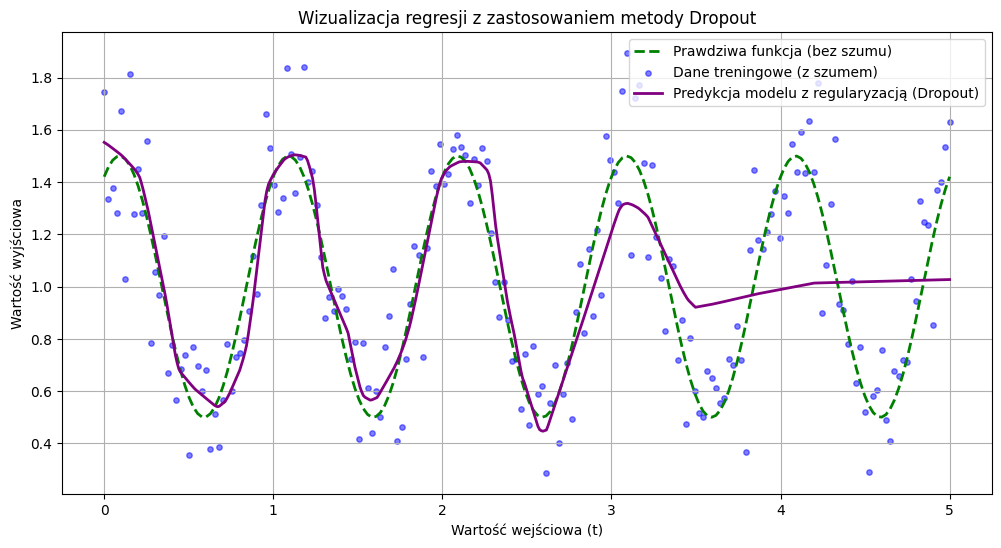

In [22]:
t_plot = np.linspace(0, 5, 500).reshape(-1, 1)

predictions_dropout = model_dropout.predict(t_plot, verbose=0)

plt.figure(figsize=(12, 6))

t_original = np.linspace(0, 5, 200)
plt.plot(t_original, r_org, color='green', label='Prawdziwa funkcja (bez szumu)', linewidth=2, linestyle='--')

plt.scatter(x_train, y_train, color='blue', s=15, alpha=0.5, label='Dane treningowe (z szumem)')

plt.plot(t_plot, predictions_dropout, color='purple', label='Predykcja modelu z regularyzacją (Dropout)', linewidth=2)

plt.title('Wizualizacja regresji z zastosowaniem metody Dropout')
plt.xlabel('Wartość wejściowa (t)')
plt.ylabel('Wartość wyjściowa')
plt.legend()
plt.grid(True)
plt.show()

Eksperyment 2: Regularyzacja L1

In [35]:
model_l1 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    
    # Zmniejszamy siłę kary z 1e-4 na 1e-5
    tf.keras.layers.Dense(128, activation='relu', 
                          kernel_regularizer=tf.keras.regularizers.L1(l1=1e-5)),
    
    tf.keras.layers.Dense(128, activation='relu', 
                          kernel_regularizer=tf.keras.regularizers.L1(l1=1e-5)),
    
    tf.keras.layers.Dense(128, activation='relu', 
                          kernel_regularizer=tf.keras.regularizers.L1(l1=1e-5)),
    
    tf.keras.layers.Dense(1)
])

model_l1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_l1 = model_l1.fit(
    x_train_reshaped,
    y_train,
    epochs=1500,
    validation_data=(x_test_reshaped, y_test),
    verbose=0,
    callbacks=[ProgressMonitor()] 
)

train_loss_l1 = model_l1.evaluate(x_train_reshaped, y_train, verbose=0)[0]
test_loss_l1 = model_l1.evaluate(x_test_reshaped, y_test, verbose=0)[0]
print(f"Błąd treningowy (L1): {train_loss_l1:.4f} | Błąd testowy (L1): {test_loss_l1:.4f}")


Epoka    0 | Błąd treningowy: 0.7724 | Błąd testowy: 0.4286
Epoka  100 | Błąd treningowy: 0.1479 | Błąd testowy: 0.1754
Epoka  200 | Błąd treningowy: 0.1289 | Błąd testowy: 0.1503
Epoka  300 | Błąd treningowy: 0.1196 | Błąd testowy: 0.1337
Epoka  400 | Błąd treningowy: 0.1030 | Błąd testowy: 0.1205
Epoka  500 | Błąd treningowy: 0.0931 | Błąd testowy: 0.1104
Epoka  600 | Błąd treningowy: 0.0873 | Błąd testowy: 0.1017
Epoka  700 | Błąd treningowy: 0.0839 | Błąd testowy: 0.1035
Epoka  800 | Błąd treningowy: 0.0729 | Błąd testowy: 0.0956
Epoka  900 | Błąd treningowy: 0.0768 | Błąd testowy: 0.0987
Epoka 1000 | Błąd treningowy: 0.0780 | Błąd testowy: 0.1047
Epoka 1100 | Błąd treningowy: 0.0719 | Błąd testowy: 0.0941
Epoka 1200 | Błąd treningowy: 0.0722 | Błąd testowy: 0.0937
Epoka 1300 | Błąd treningowy: 0.0857 | Błąd testowy: 0.1006
Epoka 1400 | Błąd treningowy: 0.0640 | Błąd testowy: 0.0857
Błąd treningowy (L1): 0.0618 | Błąd testowy (L1): 0.0809


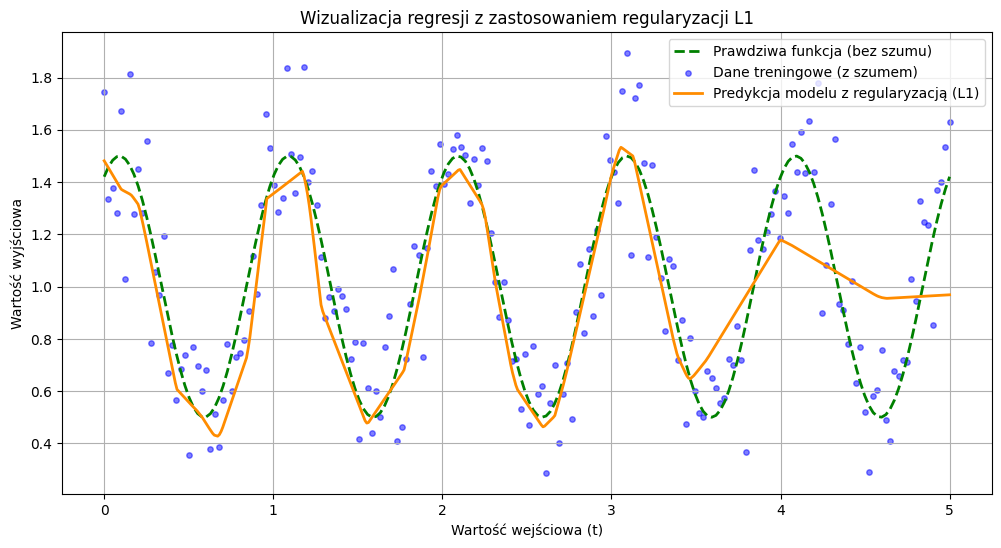

In [36]:
t_plot = np.linspace(0, 5, 500).reshape(-1, 1)

predictions_l1 = model_l1.predict(t_plot, verbose=0)

plt.figure(figsize=(12, 6))

t_original = np.linspace(0, 5, 200)
plt.plot(t_original, r_org, color='green', label='Prawdziwa funkcja (bez szumu)', linewidth=2, linestyle='--')

plt.scatter(x_train, y_train, color='blue', s=15, alpha=0.5, label='Dane treningowe (z szumem)')

plt.plot(t_plot, predictions_l1, color='darkorange', label='Predykcja modelu z regularyzacją (L1)', linewidth=2)

plt.title('Wizualizacja regresji z zastosowaniem regularyzacji L1')
plt.xlabel('Wartość wejściowa (t)')
plt.ylabel('Wartość wyjściowa')
plt.legend()
plt.grid(True)
plt.show()

3. Eksperyment 3: Regularyzacja L2

In [39]:
model_l2 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    
    tf.keras.layers.Dense(128, activation='relu', 
                          kernel_regularizer=tf.keras.regularizers.L2(1e-5)),
    
    tf.keras.layers.Dense(128, activation='relu', 
                          kernel_regularizer=tf.keras.regularizers.L2(1e-5)),
    
    tf.keras.layers.Dense(128, activation='relu', 
                          kernel_regularizer=tf.keras.regularizers.L2(1e-5)),
    
    tf.keras.layers.Dense(1)
])

model_l2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_l2 = model_l2.fit(
    x_train_reshaped,
    y_train,
    epochs=1500,
    validation_data=(x_test_reshaped, y_test),
    verbose=0,
    callbacks=[ProgressMonitor()] 
)

Epoka    0 | Błąd treningowy: 0.7733 | Błąd testowy: 0.5282
Epoka  100 | Błąd treningowy: 0.1372 | Błąd testowy: 0.1705
Epoka  200 | Błąd treningowy: 0.1236 | Błąd testowy: 0.1545
Epoka  300 | Błąd treningowy: 0.1129 | Błąd testowy: 0.1312
Epoka  400 | Błąd treningowy: 0.1029 | Błąd testowy: 0.1190
Epoka  500 | Błąd treningowy: 0.0977 | Błąd testowy: 0.1160
Epoka  600 | Błąd treningowy: 0.0875 | Błąd testowy: 0.1087
Epoka  700 | Błąd treningowy: 0.0844 | Błąd testowy: 0.1013
Epoka  800 | Błąd treningowy: 0.0851 | Błąd testowy: 0.0981
Epoka  900 | Błąd treningowy: 0.0789 | Błąd testowy: 0.0932
Epoka 1000 | Błąd treningowy: 0.0908 | Błąd testowy: 0.1066
Epoka 1100 | Błąd treningowy: 0.0714 | Błąd testowy: 0.0921
Epoka 1200 | Błąd treningowy: 0.0703 | Błąd testowy: 0.0921
Epoka 1300 | Błąd treningowy: 0.0666 | Błąd testowy: 0.0891
Epoka 1400 | Błąd treningowy: 0.0693 | Błąd testowy: 0.0935


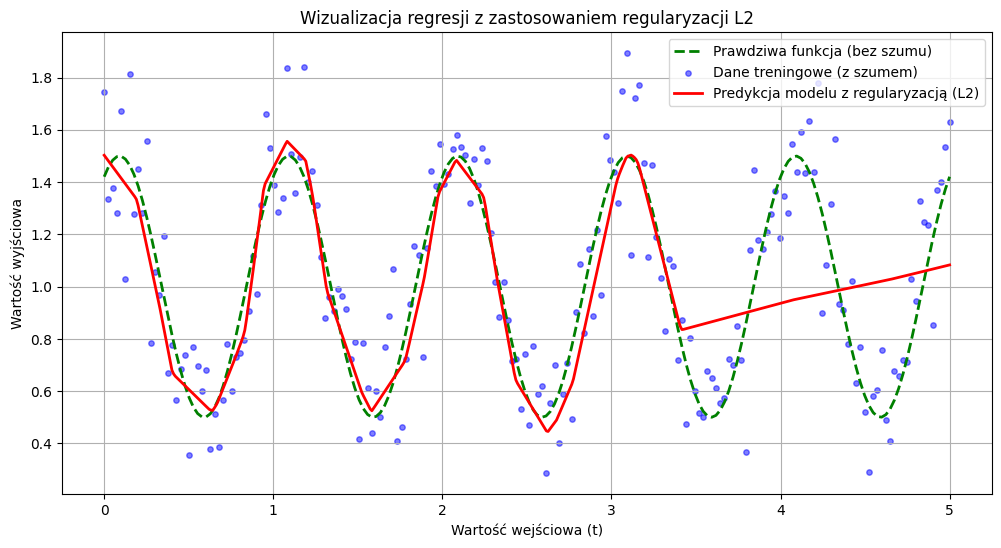

In [40]:
t_plot = np.linspace(0, 5, 500).reshape(-1, 1)
predictions_l2 = model_l2.predict(t_plot, verbose=0)

plt.figure(figsize=(12, 6))

t_original = np.linspace(0, 5, 200)
plt.plot(t_original, r_org, color='green', label='Prawdziwa funkcja (bez szumu)', linewidth=2, linestyle='--')
plt.scatter(x_train, y_train, color='blue', s=15, alpha=0.5, label='Dane treningowe (z szumem)')

plt.plot(t_plot, predictions_l2, color='red', label='Predykcja modelu z regularyzacją (L2)', linewidth=2)

plt.title('Wizualizacja regresji z zastosowaniem regularyzacji L2')
plt.xlabel('Wartość wejściowa (t)')
plt.ylabel('Wartość wyjściowa')
plt.legend()
plt.grid(True)
plt.show()